In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
DATASET_PATH="/content/drive/MyDrive/Mpiigaze"

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("dhruv413/mpiigaze")

# print("Path to dataset files:", path)

In [4]:
DATA="/content/drive/MyDrive/Mpiigaze/versions/1/MPIIGaze/Data/Normalized"

In [5]:
import os

In [6]:
os.listdir(DATA)

['p00',
 'p01',
 'p02',
 'p03',
 'p04',
 'p05',
 'p06',
 'p07',
 'p08',
 'p09',
 'p10',
 'p11',
 'p12',
 'p13',
 'p14']

In [7]:
import scipy.io as so

In [8]:
data=so.loadmat(f"{DATA}/p00/day02.mat")

In [9]:
d=data['data'][0,0]

In [10]:
d.dtype

dtype([('right', 'O'), ('left', 'O')])

In [11]:
right=d['right'][0,0]
left=d['left'][0,0]

In [12]:
left.dtype

dtype([('gaze', 'O'), ('image', 'O'), ('pose', 'O')])

In [13]:
Xl=left["image"]
Xr=right["image"]
Y=left["gaze"]

In [14]:
print(Y[0])

[-0.2289948   0.19100452 -0.9545044 ]


In [15]:
print(Xl.shape)
print(Y.shape)

(858, 36, 60)
(858, 3)


In [16]:
import matplotlib.pyplot as plt


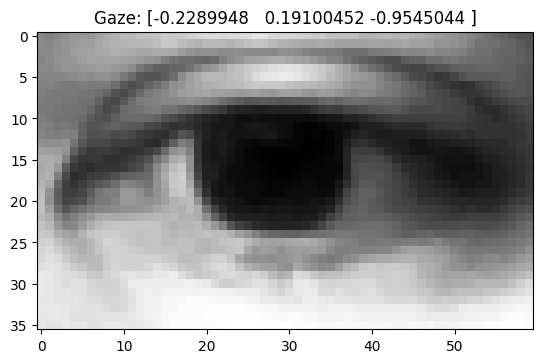

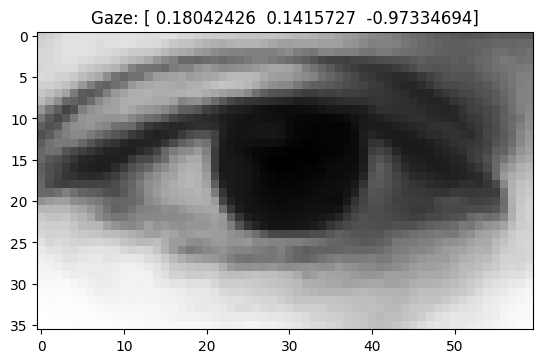

In [17]:
plt.imshow(Xl[0], cmap='gray')
plt.title(f"Gaze: {Y[0]}")
plt.show()

plt.imshow(Xr[1], cmap='gray')
plt.title(f"Gaze: {Y[1]}")
plt.show()

In [18]:
import numpy as np

def convert(gaze):
    x_angle = gaze[0]

    if x_angle < -0.1: #if eye is move on left side
        return 0
    elif x_angle > 0.1: #if eye is move on right side
        return 2
    else:
        return 1

labels = np.array([convert(g) for g in Y])

In [19]:
#Channel Dimension- 1 means grayscale channel
Xl_reshaped = np.expand_dims(Xl, axis=-1)
Xr_reshaped = np.expand_dims(Xr, axis=-1)

print(f"Shape of Xl_reshaped: {Xl_reshaped.shape}")
print(f"Shape of Xr_reshaped: {Xr_reshaped.shape}")

Shape of Xl_reshaped: (858, 36, 60, 1)
Shape of Xr_reshaped: (858, 36, 60, 1)


In [20]:
#Normalized Pixel Values

Xl_reshaped = Xl_reshaped / 255.0
Xr_reshaped = Xr_reshaped / 255.0

In [31]:
y = Y

In [40]:
#Combined Left and Right Eyes

# X = np.concatenate([Xl_reshaped, Xr_reshaped], axis=0)
# y = np.concatenate([labels, labels], axis=0)

# print(X.shape)
# print(y.shape)
Y = left["gaze"]

X = np.concatenate([Xl_reshaped, Xr_reshaped], axis=0)
y = np.concatenate([Y, Y], axis=0)

print(X.shape)
print(y.shape)

(1716, 36, 60, 1)
(1716, 3)


In [42]:
#X (100%)
#  │
#  ├── X_train (70%)
#  │
#  └── X_temp (30%)
#         │
#         ├── X_val (15%)
#         └── X_test (15%)


from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1201, 36, 60, 1)
(257, 36, 60, 1)
(258, 36, 60, 1)


In [43]:
#pytorch expects (samples, channels, height, width)
#output-(1201, 1, 36, 60)
X_train = np.transpose(X_train, (0,3,1,2))
X_val = np.transpose(X_val, (0,3,1,2))
X_test = np.transpose(X_test, (0,3,1,2))

In [44]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val   = torch.tensor(y_val, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [45]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [53]:
import torch
import torch.nn as nn

class GazeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*9*15*2,128),
            nn.ReLU(),
            nn.Linear(128,3)
        )

    def forward(self,xl,xr):
        xl = self.conv(xl)
        xr = self.conv(xr)

        xl = xl.view(xl.size(0),-1)
        xr = xr.view(xr.size(0),-1)

        x = torch.cat((xl,xr),dim=1)
        return self.fc(x)


In [54]:
#for regression use MSLoss
criterion = nn.MSELoss()

In [55]:
print(y_train.shape)

torch.Size([1201, 3])


In [58]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 15

for epoch in range(epochs):

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

Epoch: 1 Loss: 0.0018831501947715878
Epoch: 2 Loss: 0.0006113640265539289
Epoch: 3 Loss: 0.0013276322279125452
Epoch: 4 Loss: 0.0005943710566498339
Epoch: 5 Loss: 0.0005347681581042707
Epoch: 6 Loss: 0.0007221762207336724
Epoch: 7 Loss: 0.0007205693400464952
Epoch: 8 Loss: 0.0012098002480342984
Epoch: 9 Loss: 0.0005583312595263124
Epoch: 10 Loss: 0.0004340044688433409
Epoch: 11 Loss: 0.0006523506599478424
Epoch: 12 Loss: 0.0003250025911256671
Epoch: 13 Loss: 0.0014218533178791404
Epoch: 14 Loss: 0.0009144473588094115
Epoch: 15 Loss: 0.0010833700653165579


In [59]:
#test
model.eval()

test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

test_loss /= len(test_loader)

print("Test Loss:", test_loss)

Test Loss: 0.0023679487640038133


In [61]:
model.eval()

with torch.no_grad():
    sample = X_test[0].unsqueeze(0)
    pred = model(sample)

print("Predicted:", pred)
print("Actual:", y_test[0])

Predicted: tensor([[ 0.0017,  0.0891, -0.9740]])
Actual: tensor([ 0.0276,  0.0688, -0.9973])
